# Multiorbital/multiband (non-Abelian) quantum geometric tensor and quantum metric

The quantum geometric tensor (QGT) generalizes the Berry curvature: its antisymmetric part *is*
the Berry curvature, and its symmetric part is the quantum metric, a measure of distance between
neighboring Bloch states,

$$
Q_{ij}^{mn}(\mathbf k) = \sum_{l\notin S}
\frac{\langle u_m|\partial_{k_i}H|u_l\rangle\langle u_l|\partial_{k_j}H|u_n\rangle}
{(E_m-E_l)(E_n-E_l)},\qquad m,n\in S
$$

Because only states *outside* the chosen band subspace $S$ enter the energy denominators, it stays
well defined even for (nearly) degenerate bands in $S$, unlike a single-band Kubo formula --
`topology.chern_from_qgt` integrates its Berry-curvature part over the whole Brillouin zone,
independently reproducing the Wilson-loop `h.get_chern()`.

Chern number from the QGT       = 2.000000001848529
Chern number from Wilson loops  = 2.000000000000003


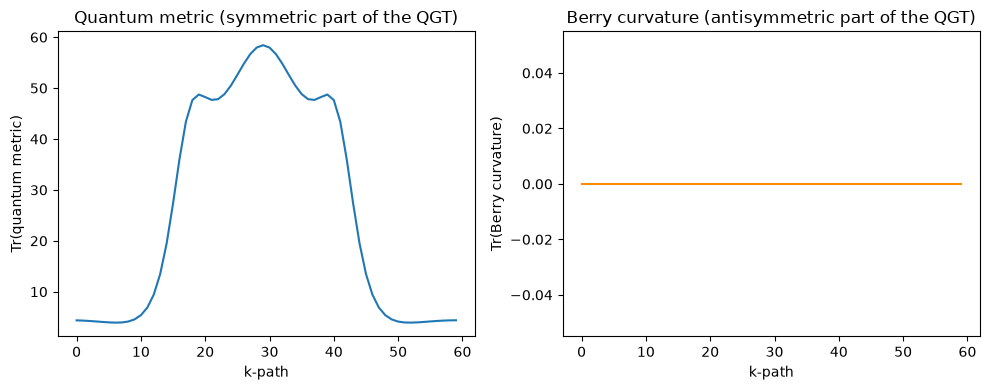

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian() # spinful by default
h.add_haldane(0.2)
h.shift_fermi(0.3) # put the Fermi level safely mid-gap

inds,gpath,omegapath = topology.quantum_geometric_tensor_path(h,occ_idxs=[0,1],nk=60)
C_qgt = topology.chern_from_qgt(h,nk=20,occ_idxs=[0,1])
print("Chern number from the QGT       =",C_qgt)
print("Chern number from Wilson loops  =",h.get_chern(nk=20))

metric_trace = np.array([np.trace(g_k).real for g_k in gpath])
berry_trace = np.array([np.trace(o_k).imag for o_k in omegapath])

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(inds,metric_trace)
axs[0].set_xlabel("k-path") ; axs[0].set_ylabel("Tr(quantum metric)")
axs[0].set_title("Quantum metric (symmetric part of the QGT)")
axs[1].plot(inds,berry_trace,c="darkorange")
axs[1].set_xlabel("k-path") ; axs[1].set_ylabel("Tr(Berry curvature)")
axs[1].set_title("Berry curvature (antisymmetric part of the QGT)")
plt.tight_layout()
plt.show()